In [12]:
import sys
sys.path.insert(0, '..')
from support.paths import resolve
import pandas as pd
import os
import numpy as np
from joblib import Parallel, delayed

In [13]:
%run ../0_Config/0_variables.ipynb

In [14]:
# Read data
X_train = pd.read_parquet("Data/X_train.parquet")
X_validate = pd.read_parquet("Data/X_validate.parquet")
X_test = pd.read_parquet("Data/X_test.parquet")
y_train = pd.read_parquet("Data/y_train.parquet")
y_validate = pd.read_parquet("Data/y_validate.parquet")
y_test = pd.read_parquet("Data/y_test.parquet")

# 1D sample-weight array of shape (n_train_rows,) — not a feature, never enters X_train.
# Each entry scales how much that row contributes to the loss during LightGBM training.
# linspace(0, 1.5, n) spaces exponents evenly across rows (oldest → newest), so
# exp() produces weights rising from 1.0 (oldest row) to ~4.5 (newest row),
# assuming X_train and y_train are aligned chronologically for training rows.
# Use X_train length because the weights correspond to training row order.
_chronological_weights = np.exp(np.linspace(0.0, 1.5, len(X_train))).astype(np.float32)

def _create_y_derivatives_per_target_col(horizon: int):
    """Compute all y (target) transformations for a given horizon."""
    
    target_col = f"h{horizon}"
    
    PRICE_TRANSFORM_SCALE = 100
    STANDARD_CLIP_PERCENTILE = 97.0
    POSITIVE_SPIKE_THRESHOLD = 150.0
    NEGATIVE_PRICE_THRESHOLD = 0.0
    POSITIVE_SPIKE_UPWEIGHT = 10.0
    NEGATIVE_SPIKE_UPWEIGHT = 7.0

    # y_train/y_validate hold all horizons as columns; slice the one being fitted
    # and convert to float32 to match LightGBM's expected dtype
    y_train_individual_target = y_train[target_col].values.astype(np.float32)
    y_validate_individual_target = y_validate[target_col].values.astype(np.float32)

    # Compute sample weights for standard model training
    # Returns a 1D sample-weight array of shape (n_train_rows,) combining two effects:
    #   - recency: weights already rise from 1.0 → ~4.5 via _chronological_weights
    #   - spike rows (price > threshold) are further multiplied by 3x
    # Net result: a recent spike row is weighted up to ~13.4x vs an old normal row,
    # preventing the standard model's loss from treating spikes as negligible noise.
    y_train_loss_weights = _chronological_weights.astype(np.float32)
    y_train_full_range_loss_weights = (_chronological_weights * np.where(y_train_individual_target > POSITIVE_SPIKE_THRESHOLD, 3.0, 1.0)).astype(np.float32)
    y_train_positive_spike_loss_weights = (_chronological_weights * np.where(y_train_individual_target > POSITIVE_SPIKE_THRESHOLD, POSITIVE_SPIKE_UPWEIGHT, 1.0)).astype(np.float32)
    y_train_negative_spike_loss_weights = (_chronological_weights * np.where(y_train_individual_target > NEGATIVE_PRICE_THRESHOLD, NEGATIVE_SPIKE_UPWEIGHT, 1.0)).astype(np.float32)

    # Compute clip threshold from training data
    y_train_individual_clipped = float(np.percentile(y_train_individual_target, STANDARD_CLIP_PERCENTILE))

    # arcsinh(y / 100) is a variance-stabilising transform that compresses large values
    # while preserving sign — unlike log, it handles negative prices. np.minimum clips
    # at the 97th-percentile threshold before transforming so extreme spikes don't
    # dominate the standard model's loss; the spike models handle those separately.
    y_train_individual_clipped_transformed = np.arcsinh(np.minimum(y_train_individual_target, y_train_individual_clipped) / PRICE_TRANSFORM_SCALE).astype(np.float32)
    y_validation_individual_clipped_transformed = np.arcsinh(np.minimum(y_validate_individual_target, y_train_individual_clipped) / PRICE_TRANSFORM_SCALE).astype(np.float32)

    # Same arcsinh transform but on the uncapped target — full price range including
    # extreme spikes and negative prices, which the specialist models are trained on.
    y_train_individual_unclipped_transformed = np.arcsinh(y_train_individual_target / PRICE_TRANSFORM_SCALE).astype(np.float32)
    y_validation_individual_unclipped_transformed = np.arcsinh(y_validate_individual_target / PRICE_TRANSFORM_SCALE).astype(np.float32)

    # Compute positive spike labels
    positive_spike_labels_train = (y_train_individual_target > POSITIVE_SPIKE_THRESHOLD).astype(np.float32)
    positive_spike_labels_validate = (y_validate_individual_target > POSITIVE_SPIKE_THRESHOLD).astype(np.float32)

    # Compute negative spike labels
    negative_spike_labels_train = (y_train_individual_target < NEGATIVE_PRICE_THRESHOLD).astype(np.float32)
    negative_spike_labels_validate = (y_validate_individual_target < NEGATIVE_PRICE_THRESHOLD).astype(np.float32)

    return {
        # 1 - target clipped and transformed
        'y_train_individual_clipped_transformed': y_train_individual_clipped_transformed,
        'y_validation_individual_clipped_transformed': y_validation_individual_clipped_transformed,

        # 2 - target no clipped but transformed
        'y_train_individual_unclipped_transformed': y_train_individual_unclipped_transformed,
        'y_validation_individual_unclipped_transformed': y_validation_individual_unclipped_transformed,
        
        # 3 - Positive target spike labels
        'positive_spike_labels_train': positive_spike_labels_train,
        'positive_spike_labels_validate': positive_spike_labels_validate,

        # 4 - Negative target spike labels
        'negative_spike_labels_train': negative_spike_labels_train,
        'negative_spike_labels_validate': negative_spike_labels_validate,

        # 5 - Weighting curve of target inc recency and spikes
        'y_train_loss_weights': y_train_loss_weights,
        'y_train_full_range_loss_weights': y_train_full_range_loss_weights,
        'y_train_positive_spike_loss_weights': y_train_positive_spike_loss_weights,
        'y_train_negative_spike_loss_weights': y_train_negative_spike_loss_weights
    }





horizon_list = list(range(1, int(os.environ["N_HORIZONS"]) + 1))

derived_targets = Parallel(n_jobs=-1, prefer="threads")(
    delayed(_create_y_derivatives_per_target_col)(h) for h in horizon_list
)

derived_targets = dict(zip(horizon_list, derived_targets))


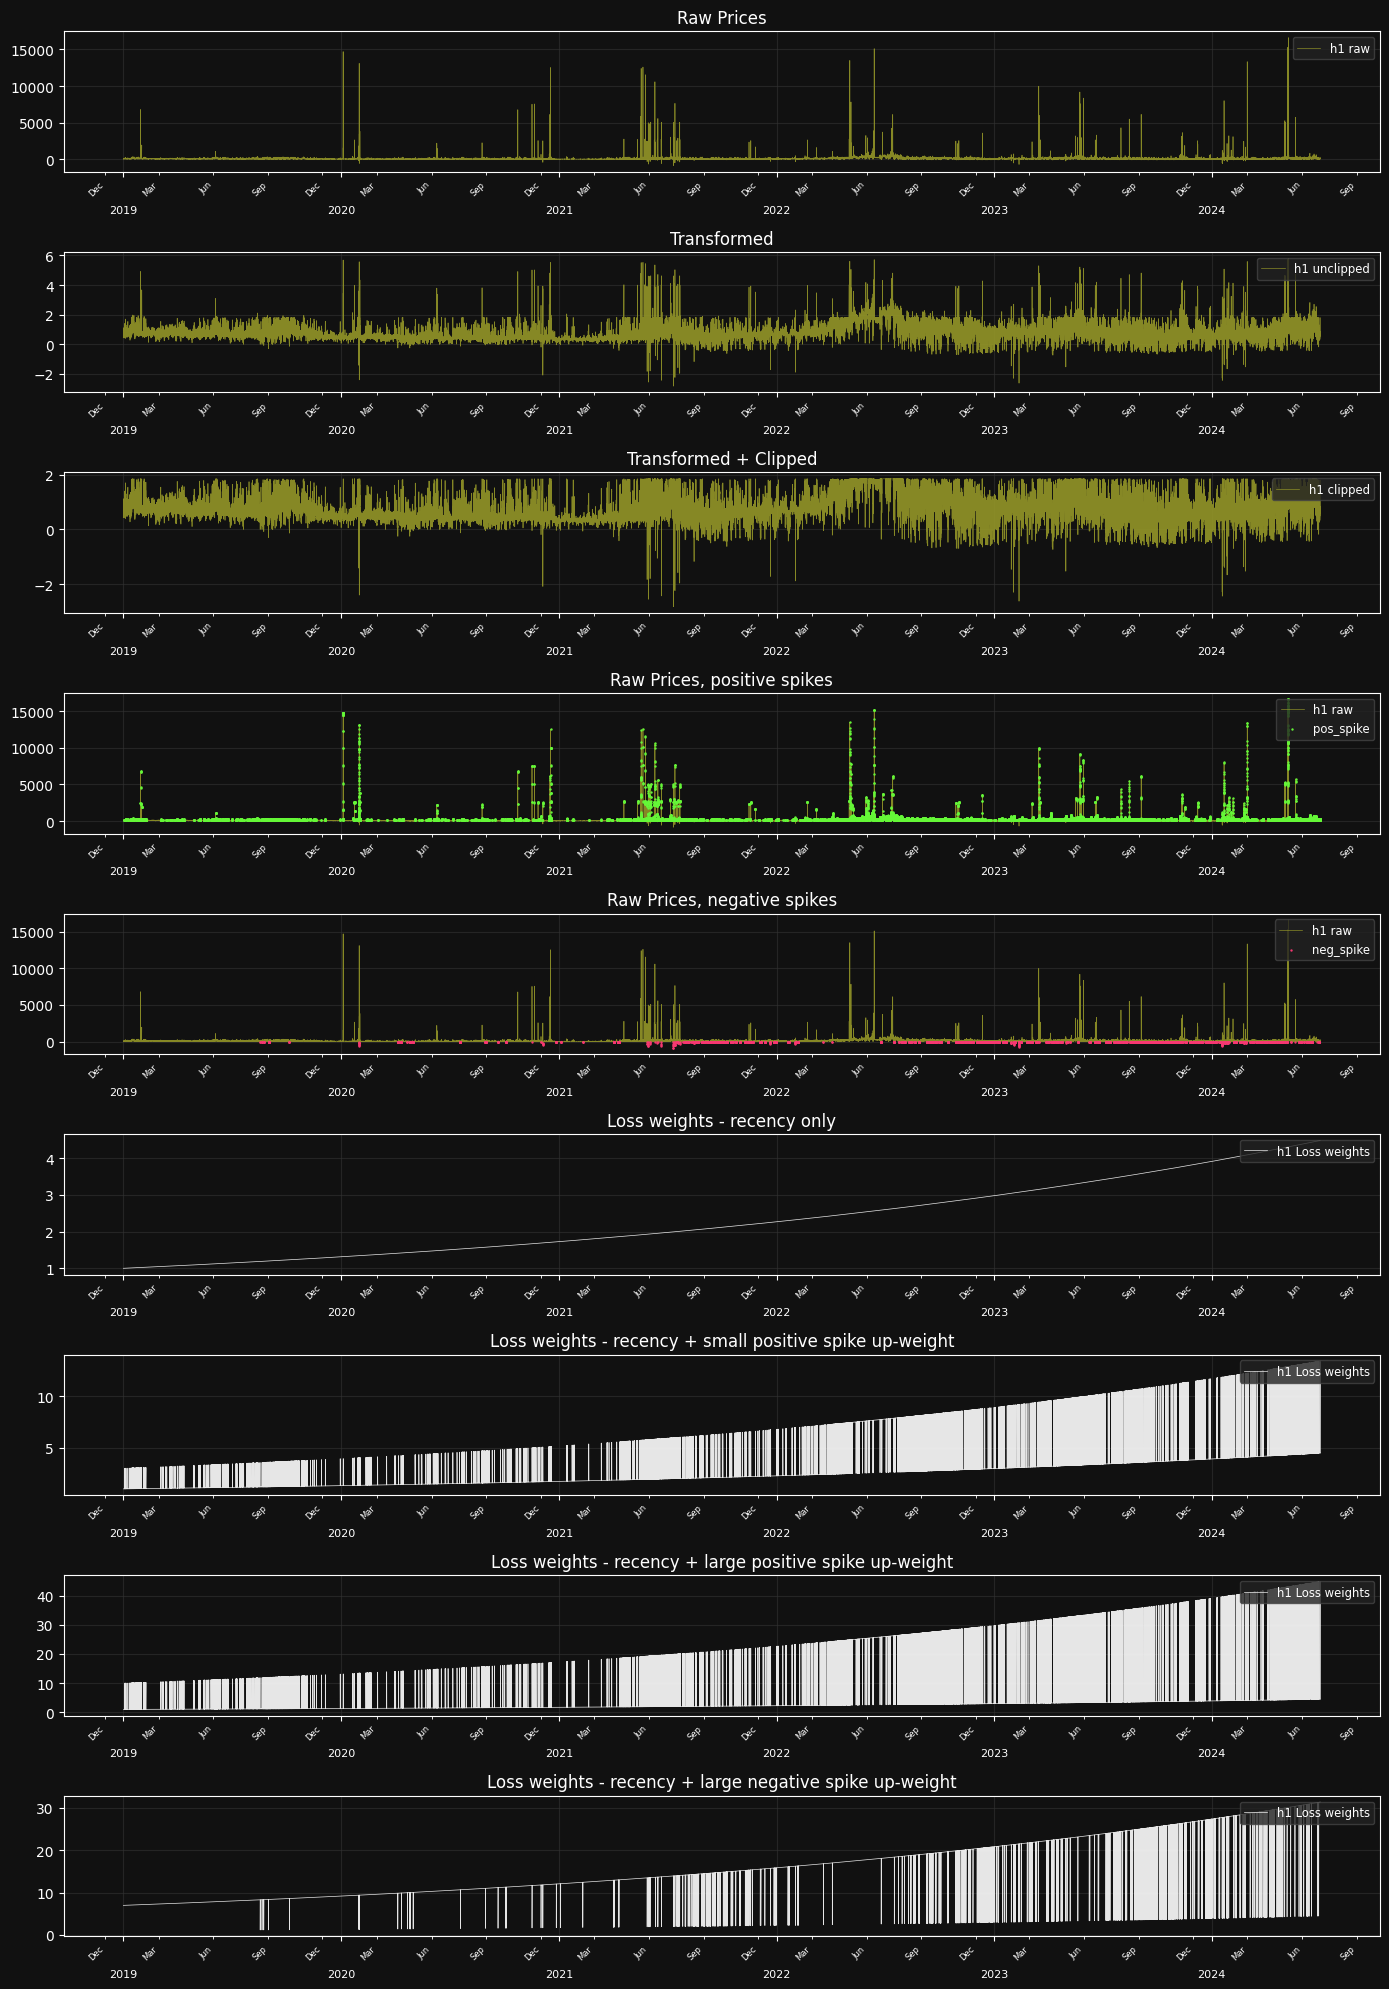

In [49]:
# Add a plotting cell to visualise derived targets for the first horizon (datetime x-axis)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

plt.style.use("dark_background")
fig, axes = plt.subplots(9, 1, figsize=(14, 20), sharex=True)
fig.patch.set_facecolor("#111111")

for ax in axes:
    ax.set_facecolor("#111111")
    ax.grid(True, color="#333333", alpha=0.6)
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")

# Only plot the first horizon
h = horizon_list[0]
d = derived_targets[h]
x = pd.to_datetime(X_train.index[:len(d["y_train_loss_weights"])])

axes[0].plot(
    x,
    y_train[f'h{h}'],
    color='#949628',
    alpha=0.9,
    label=f"h{h} raw",
    linewidth=0.5
)

axes[1].plot(
    x,
    d["y_train_individual_unclipped_transformed"],
    color='#949628',
    alpha=0.9,
    label=f"h{h} unclipped",
    linewidth=0.5
)

axes[2].plot(
    x,
    d["y_train_individual_clipped_transformed"],
    color='#949628',
    alpha=0.9,
    label=f"h{h} clipped",
    linewidth=0.5
)


axes[3].plot(
    x,
    y_train[f'h{h}'],
    color="#949628",
    alpha=0.9,
    label=f"h{h} raw",
    linewidth=0.5
)
pos_idx = np.where(d['positive_spike_labels_train'] == 1)[0]
axes[3].scatter(
    x[pos_idx],
    y_train[f'h{h}'].iloc[pos_idx],
    color="#65f838",
    s=0.5,
    label='pos_spike',
    zorder=5
)


axes[4].plot(
    x,
    y_train[f'h{h}'],
    color="#949628",
    alpha=0.9,
    label=f"h{h} raw",
    linewidth=0.5
)
neg_idx = np.where(d['negative_spike_labels_train'] == 1)[0]
axes[4].scatter(
    x[neg_idx],
    y_train[f'h{h}'].iloc[neg_idx],
    color="#f83872",
    s=0.5,
    label='neg_spike',
    zorder=5
)

axes[5].plot(
    x,
    d['y_train_loss_weights'],
    color="#FFFFFF",
    alpha=0.9,
    label=f"h{h} Loss weights",
    linewidth=0.5
)


axes[6].plot(
    x,
    d['y_train_full_range_loss_weights'],
    color="#FFFFFF",
    alpha=0.9,
    label=f"h{h} Loss weights",
    linewidth=0.5
)


axes[7].plot(
    x,
    d['y_train_positive_spike_loss_weights'],
    color="#FFFFFF",
    alpha=0.9,
    label=f"h{h} Loss weights",
    linewidth=0.5
)
axes[8].plot(
    x,
    d['y_train_negative_spike_loss_weights'],
    color="#FFFFFF",
    alpha=0.9,
    label=f"h{h} Loss weights",
    linewidth=0.5
)



# Year labels
for ax in axes:

    # Force labels to appear on ALL shared x-axes
    ax.tick_params(axis='x', which='both', labelbottom=True)

    # Year labels
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Optional month ticks
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))

    # Styling
    ax.tick_params(axis='x', which='major', pad=20, labelsize=8, colors='white')
    ax.tick_params(axis='x', which='minor', labelsize=6, colors='white')

    plt.setp(ax.get_xticklabels(which='major'), rotation=0)
    plt.setp(ax.get_xticklabels(which='minor'), rotation=45, ha='right')

# Add titles

axes[0].set_title("Raw Prices")
axes[1].set_title("Transformed")
axes[2].set_title("Transformed + Clipped")
axes[3].set_title("Raw Prices, positive spikes")
axes[4].set_title("Raw Prices, negative spikes")
axes[5].set_title("Loss weights - recency only")
axes[6].set_title("Loss weights - recency + small positive spike up-weight")
axes[7].set_title("Loss weights - recency + large positive spike up-weight")
axes[8].set_title("Loss weights - recency + large negative spike up-weight")
# Add legends
for ax in axes:
    ax.legend(
        fontsize="small",
        facecolor="#222222",
        edgecolor="#444444",
        labelcolor="white",
        loc="upper right"
    )


plt.tight_layout()
plt.show()